In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook

In [ ]:
#| hide
prepare_notebook()

## Complexity/Cost Analysis

In [ ]:
#| hide 
#| default_exp accumulate

#### Linear - Sum

In [ ]:
#| exports
def c_sum(nums):
  sum = 0
  for num in nums:
    sum += num
  return sum

In [ ]:
# nums = [random.randint(1, 10000) for _ in range(10000)]
nums = [7,4,2,3,17,18]
f'{c_sum(nums) = }'
f'{sum(nums) = }'

'c_sum(nums) = 51'

'sum(nums) = 51'

#### Linear - min
* Iterator - Walk the sequence
* Assume first one is min.
* Compare and swap min if predicate is true
* Check how many comparison happened

In [ ]:
#| exports
def c_min(seq):
  #Iterator to walk over the sequence
  it = iter(seq)
  cmp = 0
  # Assume first element as min
  winner = next(it)
  # walk over rest to compare
  for val in it:
    cmp += 1
    if val < winner:
      winner = val
  return winner, cmp

In [ ]:
f'{c_min(nums) = }'
f'{min(nums) = }'

'c_min(nums) = (2, 5)'

'min(nums) = 2'

#### Linear - max
* Iterator - Walk the sequence
* Assume first one is max.
* Compare and swap max if predicate is true
* Check how many comparison happened

In [ ]:
#| exports
def c_max(seq):
  #Iterator to walk over the sequence
  it = iter(seq)
  cmp = 0
  # Assume first element as min
  winner = next(it)
  # walk over rest to compare
  for val in it:
    cmp+=1
    # if not out_of_order(winner,val):
    if not val < winner:
      winner = val
  return winner, cmp

In [ ]:
f'{c_max(nums) = }'
f'{max(nums) = }'

'c_max(nums) = (18, 5)'

'max(nums) = 18'

[<matplotlib.lines.Line2D>]

[<matplotlib.lines.Line2D>]

Text(0.5, 0, 'n')

Text(0, 0.5, 'count')

<matplotlib.legend.Legend>

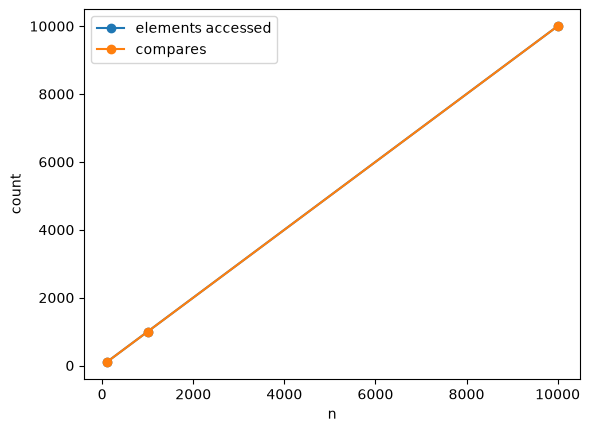

In [ ]:
ns = [100, 1_000, 10_000]
# skip the loop at 1e9 — the two counts are fixed by n
accesses = ns
compares = [n - 1 for n in ns]

plt.plot(ns, accesses, marker="o", label="elements accessed")
plt.plot(ns, compares, marker="o", label="compares")
plt.xlabel("n")
plt.ylabel("count")
plt.legend()
plt.show()

#### Quadratic - 2 Sum

In [ ]:
#| exports
def find_fraud_2sum(txns, T):
  cmp = 0
  l = len(txns)
  for t1 in txns:
    for t2 in txns:
      cmp += 1
      if t1.id != t2.id and t1.amount + t2.amount == T:
        return (t1,t2),(l,cmp)
  return (None,None),(l,cmp)


In [ ]:
Txn = namedtuple("Txn", ["id", "amount"])

transactions = [
    Txn("TXN1001", 4200),
    Txn("TXN1002", 1500),
    Txn("TXN1003", 9800),
    Txn("TXN1004", 3300),
    Txn("TXN1005", 2700),
]
T = 10_000

f'Worst Case: {find_fraud_2sum(transactions,T) = }'
print()
transactions.append(Txn("TXN1006", 5800))
f'Best Case: {find_fraud_2sum(transactions,T) = }'

'Worst Case: find_fraud_2sum(transactions,T) = ((None, None), (5, 25))'

"Best Case: find_fraud_2sum(transactions,T) = ((Txn(id='TXN1001', amount=4200), Txn(id='TXN1006', amount=5800)), (6, 6))"

#### Quadratic - 3 Sum

In [ ]:
#| exports
def find_fraud_3sum(txns, T):
    cmp = 0
    l = len(txns)
    for t1 in txns:
        for t2 in txns:
            for t3 in txns:
                cmp += 1
                ids = {t1.id, t2.id, t3.id}
                if len(ids) == 3 and t1.amount + t2.amount + t3.amount == T:
                    return (t1, t2, t3), (l, cmp)
    return (None, None, None), (l, cmp)

In [ ]:
transactions = [
    Txn("TXN1001", 4200),
    Txn("TXN1002", 1500),
    Txn("TXN1003", 9800),
    Txn("TXN1004", 3300),
    Txn("TXN1005", 2700),
    Txn("TXN1006", 1000),
]
T = 9200  # 4200 + 3300 + 1700? adjust below

f'{find_fraud_3sum(transactions, T) = }'

'find_fraud_3sum(transactions, T) = ((None, None, None), (6, 216))'

#### Plot
* Linear, Quadratic, Cubic, Logarithm

[<matplotlib.lines.Line2D>]

Text(0.5, 1.0, 'linear')

[<matplotlib.lines.Line2D>]

Text(0.5, 1.0, 'quadratic')

[<matplotlib.lines.Line2D>]

...

<matplotlib.legend.Legend>

Text(0.5, 0, 'n')

<matplotlib.legend.Legend>

Text(0.5, 0, 'n')

<matplotlib.legend.Legend>

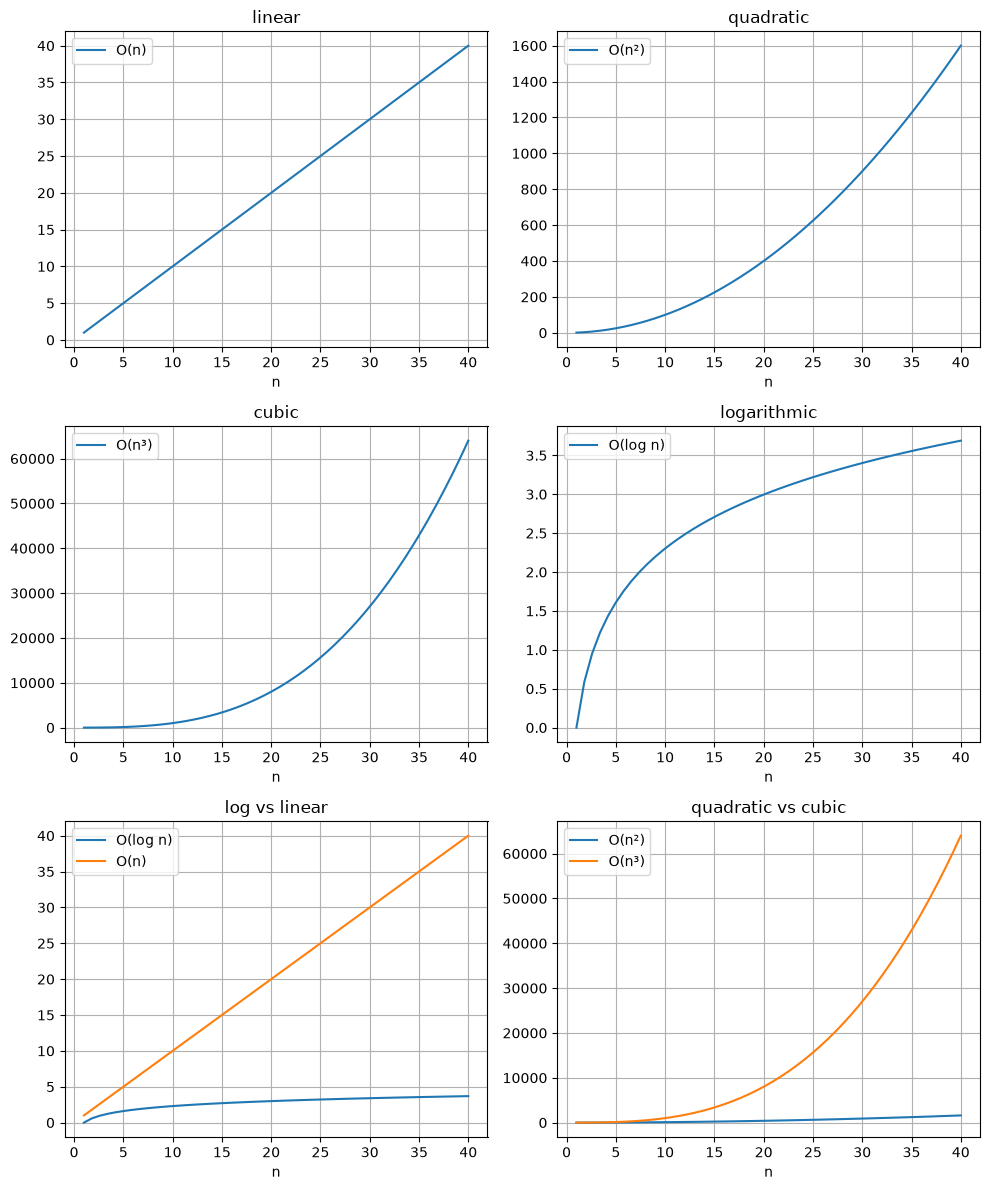

In [ ]:
ns = np.linspace(1, 40, 50)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].plot(ns, ns, label="O(n)")
axes[0, 0].set_title("linear")

axes[0, 1].plot(ns, ns**2, label="O(n²)")
axes[0, 1].set_title("quadratic")

axes[1, 0].plot(ns, ns**3, label="O(n³)")
axes[1, 0].set_title("cubic")

axes[1, 1].plot(ns, np.log(ns), label="O(log n)")
axes[1, 1].set_title("logarithmic")

axes[2, 0].plot(ns, np.log(ns), label="O(log n)")
axes[2, 0].plot(ns, ns, label="O(n)")
axes[2, 0].set_title("log vs linear")

axes[2, 1].plot(ns, ns**2, label="O(n²)")
axes[2, 1].plot(ns, ns**3, label="O(n³)")
axes[2, 1].set_title("quadratic vs cubic")

for row in axes:
    for ax in row:
        ax.set_xlabel("n")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()